# Behavioral Feature Correlation Heatmap

Uses the same `player_stats` table built in `player_Segmentation.ipynb` — one row
per player, with `BettingVolatility` (std of log bet-ratio bet-to-bet) and
`LossChasingRate` (share of after-loss bets that increased in size).

If two behavioral features are highly correlated, they're measuring close to the
same thing, and feeding both into XGBoost just adds redundant noise instead of
new signal. This heatmap is a quick check on how independent our two features
actually are before they go into a model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from poker_coach.config import BUSTABIT_DATA_FILE, GRAPE_SODA, MUTED_TEAL

sns.set_theme(style='darkgrid')

MIN_AFTER_LOSS_BETS = 10  # need enough after-loss bets for a player's chasing rate to be meaningful

df = pd.read_csv(BUSTABIT_DATA_FILE, na_values=['NA'], parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)

df = df.sort_values(['Username', 'PlayDate']).reset_index(drop=True)  # each player's bets in time order
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)
df['BetIncreased'] = df['Bet'] > df['PrevBet']

seq_df = df.dropna(subset=['PrevBet', 'PrevWon']).copy()  # drop each player's first-ever bet (no history)
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})
seq_df['LogBetRatio'] = np.log(seq_df['Bet'] / seq_df['PrevBet'])  # log so doubling and halving are equally "sized"

# same player_stats build as player_Segmentation.ipynb
volatility = seq_df.groupby('Username')['LogBetRatio'].std().rename('BettingVolatility')

after_loss = seq_df[seq_df['PrevOutcome'] == 'After Loss']
loss_chasing = after_loss.groupby('Username')['BetIncreased'].agg(
    LossChasingRate='mean', NumAfterLossBets='size'
)

player_stats = loss_chasing.join(volatility, how='inner')
player_stats = player_stats[player_stats['NumAfterLossBets'] >= MIN_AFTER_LOSS_BETS].dropna()
player_stats = player_stats.reset_index()

print(f"{len(player_stats):,} players with at least {MIN_AFTER_LOSS_BETS} after-loss bets")
player_stats.head()

506 players with at least 10 after-loss bets


,Username,LossChasingRate,NumAfterLossBets,BettingVolatility
0,-Nothing-,0.434783,23,2.300588
1,-t-,0.466667,15,2.336051
2,-tuyul-,0.312500,16,1.338306
3,01010100b,0.230769,13,1.074465
4,1225,0.603774,53,1.747917


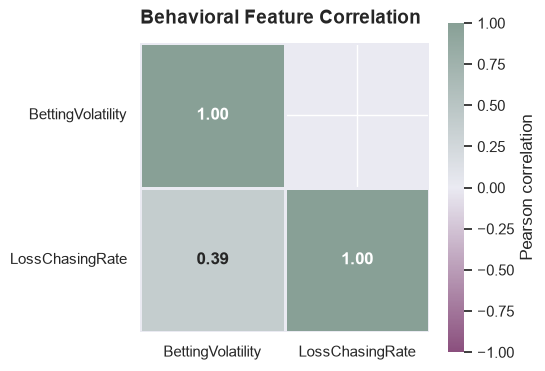

,BettingVolatility,LossChasingRate
BettingVolatility,1.000000,0.387909
LossChasingRate,0.387909,1.000000


In [2]:
from matplotlib.colors import LinearSegmentedColormap

FEATURES = ['BettingVolatility', 'LossChasingRate']  # NumAfterLossBets is a sample-size cutoff, not a behavior

corr = player_stats[FEATURES].corr()

# diverging: grape soda (negative) <-> neutral midpoint <-> muted teal (positive),
# the same two colors this project already uses to contrast a behavioral dichotomy
diverging_cmap = LinearSegmentedColormap.from_list('grape_teal_diverging', [GRAPE_SODA, '#EAEAF2', MUTED_TEAL])

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # each pair only needs to be shown once

fig, ax = plt.subplots(figsize=(5.5, 4.8))

sns.heatmap(
    corr, mask=mask, cmap=diverging_cmap, vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    linewidths=2, linecolor='#EAEAF2', square=True,
    cbar_kws={'label': 'Pearson correlation', 'shrink': 0.8},
    ax=ax,
)

ax.set_title('Behavioral Feature Correlation', fontsize=14, fontweight='bold', loc='left', pad=14)
ax.tick_params(axis='both', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

corr

## Interpretation

`BettingVolatility` and `LossChasingRate` correlate at **r ≈ 0.39** across the
506 players in `player_stats`. That's a real, moderate positive relationship —
players who swing their bet size around more from bet to bet also tend to raise
their bet after a loss more often — but it's far from redundant (r would need to
be closer to ±0.8–0.9 before one feature is just standing in for the other).

For the XGBoost model, this means both features are worth keeping: they're
correlated enough to reflect a shared underlying tendency (erratic, escalation-prone
betting), but distinct enough that each still carries information the other doesn't
capture on its own.